### Classificação dos textos do Twitter X com o spaCY IA


Download da base de dados do Twitter em português e aplicar o mesmo método utilizado nas aulas anteriores (a base de dados encontra-se nos materiais do curso)


anaocnda ambiente Maq2

### 26.7) Classificação de textos do Twitter com spaCy

In [95]:
# Importação e instalação das bibliotecas

import spacy
spacy.__version__

'3.7.5'

In [96]:
#!pip install spacy
#!python -m spacy download pt_core_news_sm

In [97]:
import pandas as pd
import string
import spacy
#import en_core_web_sm
import random
import seaborn as sns
import numpy as np
import re

# Carregamento das bases de dados

- Link Kaggle: https://www.kaggle.com/augustop/portuguese-tweets-for-sentiment-analysis#TweetsNeutralHash.csv

## Base de treinamento

- Negative label: 0 (palavras negativas)

- Positive label: 1 (palavras positivas)

In [98]:
import sys
sys.prefix


'/home/fabiene/anaconda3/envs/Maq2'

In [99]:
import sys
print(sys.executable)


/home/fabiene/anaconda3/envs/Maq2/bin/python


In [100]:
#!pip install https://github.com/explosion/spacy-models/releases/download/en_core_web_sm-3.7.1/en_core_web_sm-3.7.1-py3-none-any.whl


In [101]:
# correto
#!pip show en-core-web-sm


In [102]:
#!python -m spacy download en_core_web_sm


In [103]:
import spacy
print(spacy.__version__)


3.7.5


In [104]:
#nlp = spacy.load("en_core_web_sm")
#print("Modelo carregado com sucesso!")

In [105]:
base_treinamento = pd.read_csv('Train50.csv', delimiter=';')

In [106]:
base_treinamento.shape

(50000, 5)

In [107]:
base_treinamento.head()

,id,tweet_text,tweet_date,sentiment,query_used
0,1050785521201541121,@Laranjito76 A pessoa certa para isso seria o ...,Fri Oct 12 16:29:25 +0000 2018,1,:)
1,1050785431955140608,"@behin_d_curtain Para mim, é precisamente o co...",Fri Oct 12 16:29:04 +0000 2018,1,:)
2,1050785401248645120,Vou fazer um video hoje... estou pensando em f...,Fri Oct 12 16:28:56 +0000 2018,1,:)
3,1050785370982547461,"aaaaaaaa amei tanto essas polaroids, nem sei e...",Fri Oct 12 16:28:49 +0000 2018,1,:)
4,1050785368902131713,Valoriza o coração do menininho que vc tem. El...,Fri Oct 12 16:28:49 +0000 2018,1,:)


In [108]:
# id, tweet_text, tweet_date


In [109]:
#sns.countplot(base_treinamento['sentiment'], label = 'Contagem');

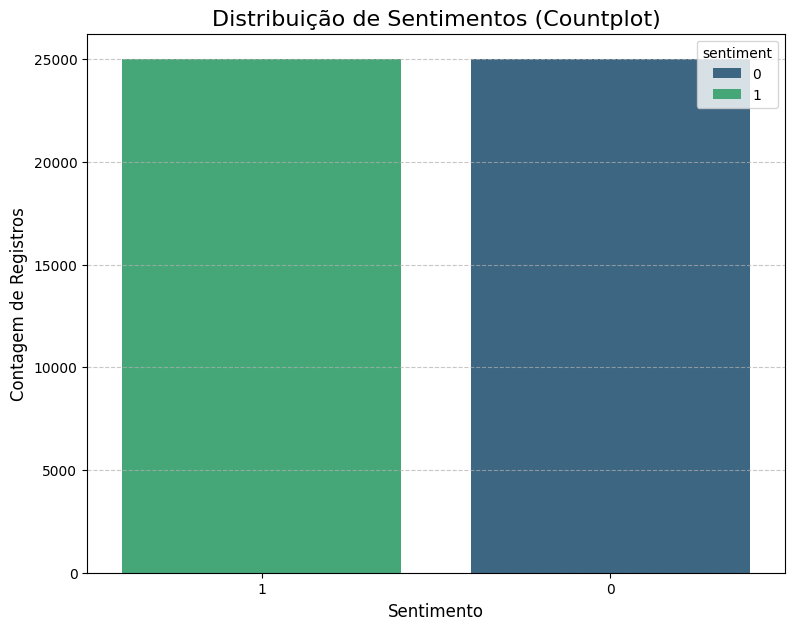

In [110]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Definir o tamanho da figura
plt.figure(figsize=(9, 7)) 

# 2. Criar o gráfico
# sns.countplot espera que você use o parâmetro 'x' ou 'y' com o nome da coluna (string)
# e o parâmetro 'data' com o DataFrame.
sns.countplot(
    x='sentiment', 
    data=base_treinamento,
    # 1. Diz explicitamente que a cor (hue) é determinada pelo 'sentiment' (x).
    hue='sentiment',    
    # 3. Ordenar as barras pela contagem (opcional, mas recomendado)
    order=base_treinamento['sentiment'].value_counts().index, 
    
    # 4. Escolher uma paleta de cores, como 'viridis' ou 'Set2'
    palette='viridis' 
)

# 5. Adicionar Título e Rótulos
plt.title('Distribuição de Sentimentos (Countplot)', fontsize=16)
plt.xlabel('Sentimento', fontsize=12)
plt.ylabel('Contagem de Registros', fontsize=12)

# 6. Mostrar o gráfico
plt.grid(axis='y', linestyle='--', alpha=0.7) # Adiciona linhas de grade suaves no eixo Y
plt.show()

In [111]:
base_treinamento.drop(['id', 'tweet_date', 'query_used'], axis = 1, inplace=True)

In [112]:
base_treinamento.head()

,tweet_text,sentiment
0,@Laranjito76 A pessoa certa para isso seria o ...,1
1,"@behin_d_curtain Para mim, é precisamente o co...",1
2,Vou fazer um video hoje... estou pensando em f...,1
3,"aaaaaaaa amei tanto essas polaroids, nem sei e...",1
4,Valoriza o coração do menininho que vc tem. El...,1


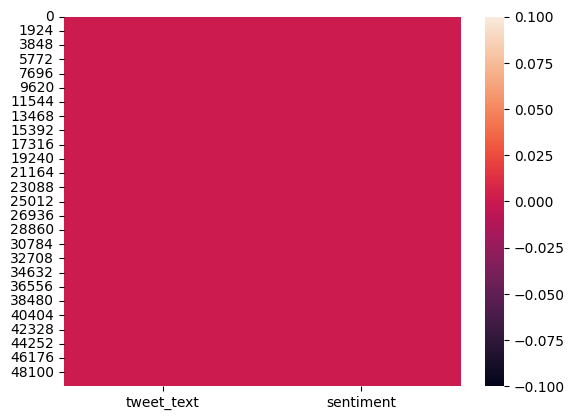

In [113]:
sns.heatmap(pd.isnull(base_treinamento));

## Base de teste

In [114]:
base_teste = pd.read_csv('Test.csv', delimiter=';')

In [115]:
base_teste.head()

,id,tweet_text,tweet_date,sentiment,query_used
0,1029536486021099522,@Gazo1a Nossa! Muito obrigada :),Wed Aug 15 01:13:20 +0000 2018,1,:)
1,1029536496368406528,@BerzGamer vai pa puta que te pariu :),Wed Aug 15 01:13:23 +0000 2018,1,:)
2,1029536531655131137,QUER MAIS DESCONTOS? (14/08) ⭐⭐⭐⭐⭐ 🌐 Confira n...,Wed Aug 15 01:13:31 +0000 2018,1,:)
3,1029536560117678081,"EU VOU PEGAR VCS, ME AJUDEM GALERA, PELO AMOR ...",Wed Aug 15 01:13:38 +0000 2018,1,:)
4,1029536605852377088,Estávamos em casa do Zé e eu estava a morrer d...,Wed Aug 15 01:13:49 +0000 2018,1,:)


In [116]:
base_teste.shape

(5000, 5)

In [117]:
base_teste.drop(['id', 'tweet_date', 'query_used'], axis = 1, inplace=True)

In [118]:
base_teste.head()

,tweet_text,sentiment
0,@Gazo1a Nossa! Muito obrigada :),1
1,@BerzGamer vai pa puta que te pariu :),1
2,QUER MAIS DESCONTOS? (14/08) ⭐⭐⭐⭐⭐ 🌐 Confira n...,1
3,"EU VOU PEGAR VCS, ME AJUDEM GALERA, PELO AMOR ...",1
4,Estávamos em casa do Zé e eu estava a morrer d...,1


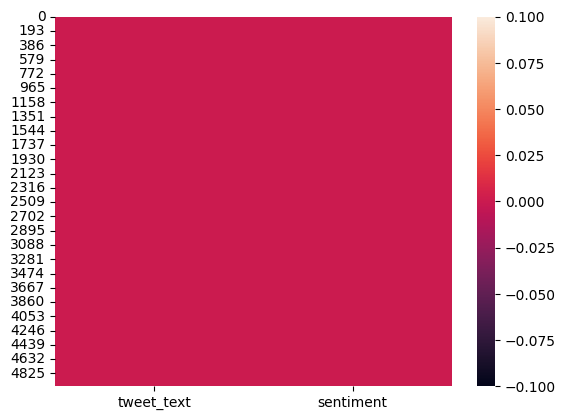

In [119]:
sns.heatmap(pd.isnull(base_teste));

# Função para pré-processamento dos textos

- Letras minúsculas
- Nome do usuário (@)
- URLs
- Espaços em branco
- Emoticons
- Stop words
- Lematização
- Pontuações

In [120]:
import spacy
nlp = spacy.load("en_core_web_sm")
print("Modelo carregado com sucesso!")


Modelo carregado com sucesso!


In [121]:
# pln = en_core_web_sm.load()
# pln


In [122]:
# lista do stopwords

In [123]:
from spacy.lang.pt.stop_words import STOP_WORDS
stop_words = STOP_WORDS

In [124]:
def preprocessamento(texto):
  # Letras minúsculas
  texto = texto.lower()

  # Nome do usuário, retirar o @nome_do_usuario, letras, números e caracteres. 
  texto = re.sub(r"@[A-Za-z0-9$-_@.&+]+", ' ', texto)

  # URLs retirar o site
  texto = re.sub(r"https?://[A-Za-z0-9./]+", ' ', texto)

  # Espaços em branco  (para retirar os espaços em branco)
  texto = re.sub(r" +", ' ', texto)

  # Emoticons  # substituir dados com emogi positiva e negativa
  lista_emocoes = {':)': 'emocaopositiva',
                   ':d': 'emocaopositiva',
                   ':(': 'emocaonegativa'}
  for emocao in lista_emocoes:
    texto = texto.replace(emocao, lista_emocoes[emocao])

  # Lematização
  documento = nlp(texto)
    
  # usar a lematização
  lista = []
  for token in documento:
    lista.append(token.lemma_)

  # Stop words e pontuações serão retirados
  lista = [palavra for palavra in lista if palavra not in stop_words and palavra not in string.punctuation]
  lista = ' '.join([str(elemento) for elemento in lista if not elemento.isdigit()])

  return lista

# Pré-processamento da base de dados

### Limpeza dos textos

In [125]:
base_treinamento.head(10) # base original

,tweet_text,sentiment
0,@Laranjito76 A pessoa certa para isso seria o ...,1
1,"@behin_d_curtain Para mim, é precisamente o co...",1
2,Vou fazer um video hoje... estou pensando em f...,1
3,"aaaaaaaa amei tanto essas polaroids, nem sei e...",1
4,Valoriza o coração do menininho que vc tem. El...,1
5,@KingJokerLeto mas amiga eu to aqui ainda :),1
6,"@RivasJairo Bravo, Jairo!!! :)))",1
7,@inquilinasls @Spotify socorro ksoaksosks acho...,1
8,"@chimekarlla gosto muito de fazenda :) , mas m...",1
9,Amanha vou ver venom :D,1


In [126]:
base_treinamento['tweet_text'] = base_treinamento['tweet_text'].apply(preprocessamento)

In [127]:
base_treinamento.head(10) #base agora tratada

,tweet_text,sentiment
0,pessoa certa vale azevedo emocaopositiva,1
1,mim precisamente contrário emocaopositiva ch...,1
2,vou video hoje ... pensando falar meta csgo pa...,1
3,aaaaaaaa amei polaroid expressar to apaixonada...,1
4,valoriza coração menininho vc diferente faça s...,1
5,amiga to emocaopositiva,1
6,bravo jairo emocaopositiva,1
7,socorro ksoaksosk acho to usando caixinha so...,1
8,gosto fazenda emocaopositiva morro medo gali...,1
9,amanha vou venom emocaopositiva,1


In [128]:
base_teste.head(10)

,tweet_text,sentiment
0,@Gazo1a Nossa! Muito obrigada :),1
1,@BerzGamer vai pa puta que te pariu :),1
2,QUER MAIS DESCONTOS? (14/08) ⭐⭐⭐⭐⭐ 🌐 Confira n...,1
3,"EU VOU PEGAR VCS, ME AJUDEM GALERA, PELO AMOR ...",1
4,Estávamos em casa do Zé e eu estava a morrer d...,1
5,Precisa :) https://t.co/DcLGDHbjT0,1
6,@Jeniabreu07 mas por acaso adoro beijos e abra...,1
7,Solteiro s sozinho sempre :),1
8,Lindezas Cortador kit Mário coleção Bia Cravol...,1
9,@otphurts Claro que sim :)),1


In [129]:
base_teste['tweet_text'] = base_teste['tweet_text'].apply(preprocessamento)

In [130]:
base_teste.head(10)

,tweet_text,sentiment
0,emocaopositiva,1
1,pa puta pariu emocaopositiva,1
2,desconto 14/08 ⭐ ⭐ ⭐ ⭐ ⭐ 🌐 confira link ➔ » co...,1
3,vou vcs I ajudem galera amor butera emocaoposi...,1
4,estávamos casa zé morrer sono chego casa fico ...,1
5,precisa emocaopositiva,1
6,acaso adoro beijos abraços hahahahaha bue fo...,1
7,solteiro s sozinho emocaopositiva,1
8,lindezas cortador kit mário coleção bia cravol...,1
9,claro emocaopositiva,1


# Tratamento da classe

In [131]:
exemplo_base_dados = [["este trabalho é agradável", {"POSITIVO": True, "NEGATIVO": False}],
                      ["este lugar continua assustador", {"POSITIVO": False, "NEGATIVO": True}]]

In [132]:
base_dados_treinamento_final = []
for texto, emocao in zip(base_treinamento['tweet_text'], base_treinamento['sentiment']):
  if emocao == 1:
    dic = ({'POSITIVO': True, 'NEGATIVO': False})
  elif emocao == 0:
    dic = ({'POSITIVO': False, 'NEGATIVO': True})

  base_dados_treinamento_final.append([texto, dic.copy()])

In [133]:
len(base_dados_treinamento_final)

50000

In [134]:
base_dados_treinamento_final[10:15]

[['simplesmente I deixam chateada coisas muitooo I iludir emocaopositiva',
  {'POSITIVO': True, 'NEGATIVO': False}],
 ['começa rotina perfeitamente consolidar escola condução :p',
  {'POSITIVO': True, 'NEGATIVO': False}],
 ['amigo apaixonado vc — recíproco emocaopositiva',
  {'POSITIVO': True, 'NEGATIVO': False}],
 ['  gajo bacano vê I aleijas espero silva sejam felize emocaopositiva',
  {'POSITIVO': True, 'NEGATIVO': False}],
 ['tou video cabrinhas bebés emocaopositiva',
  {'POSITIVO': True, 'NEGATIVO': False}]]

In [135]:
base_dados_treinamento_final[45000:45005]

[['menino pijama listrado filme triste mundo estrutura pra assistir rever to pensando nisso emocaonegativa',
  {'POSITIVO': False, 'NEGATIVO': True}],
 ['pra ido vídeo luísa raiz poliana infelizmente twitter tá ruim amanhã tento postar emocaonegativa asaventurasdepoliana099',
  {'POSITIVO': False, 'NEGATIVO': True}],
 ['to crise abstinência stranger emocaonegativa — tbm :/ to tentando',
  {'POSITIVO': False, 'NEGATIVO': True}],
 ['  tinha esquecido olhar pra pagar mensalidade turma pro curso emocaonegativa',
  {'POSITIVO': False, 'NEGATIVO': True}],
 ['comer doce comi monte hoje emocaonegativa maldição',
  {'POSITIVO': False, 'NEGATIVO': True}]]

# Criação do classificador

In [136]:
modelo = spacy.blank('pt')
categorias = modelo.add_pipe("textcat")
categorias.add_label("POSITIVO")
categorias.add_label("NEGATIVO")
historico = []

In [137]:
categorias

In [138]:
from spacy.training import Example
#Prepara o modelo para o treinamento. Isso inicializa otimizadores, taxas de aprendizado e outros ...
modelo.begin_training()
#O treinamento é executado por 3 épocas. Uma época significa que o modelo verá o conjunto de dados inteiro uma vez.
for epoca in range(3): # 3 épocas
  # random.shuffle: Embaralha os dados de treinamento a cada época.
  # Isso é crucial para evitar que o modelo aprenda a ordem dos dados e melhora a generalização.
  random.shuffle(base_dados_treinamento_final)
  #Inicializa um dicionário para rastrear as perdas (erros) do modelo durante a época atual.
  losses = {}
  # Divide o conjunto de dados embaralhado em lotes (batches) de 512 amostras (texto e rótulos).
  # O treinamento é muito mais eficiente quando feito em pequenos lotes do que em uma amostra de cada vez.
  for batch in spacy.util.minibatch(base_dados_treinamento_final, 512): # usa a rede neural para fazer a varredura nos lotes.
    # Esta é a função central que realiza o aprendizado:
    # Faz a propagação forward (o modelo faz previsões).    
    # Calcula a função de perda (o erro entre a previsão e o rótulo verdadeiro).    
    # Executa a propagação backward (cálculo dos gradientes).    
    # Aplica a otimização (ajusta os pesos internos do modelo para reduzir o erro).  
    # armazena textos e e annotations é a emoção
    textos = [modelo(texto) for texto, entities in batch]
    annotations = [{'cats': entities} for texto, entities in batch]
    examples = [Example.from_dict(doc, annotation) for doc, annotation in zip(
        textos, annotations
      )]
    modelo.update(examples, losses=losses)
    historico.append(losses)
  if epoca % 5 == 0:
    print(f'epoca {epoca} : losses')
    print(losses)

epoca 0 : losses
{'textcat': 1.7065681771718175}


In [139]:
Example

spacy.training.example.Example

In [140]:
examples[:5]

[{'doc_annotation': {'cats': {'POSITIVO': True, 'NEGATIVO': False}, 'entities': ['O', 'O', 'O', 'O', 'O'], 'spans': {}, 'links': {}}, 'token_annotation': {'ORTH': ['  ', 'queria', 'vergonha', 'foda', 'emocaopositiva'], 'SPACY': [False, True, True, True, False], 'TAG': ['', '', '', '', ''], 'LEMMA': ['', '', '', '', ''], 'POS': ['', '', '', '', ''], 'MORPH': ['', '', '', '', ''], 'HEAD': [0, 1, 2, 3, 4], 'DEP': ['', '', '', '', ''], 'SENT_START': [1, 0, 0, 0, 0]}},
 {'doc_annotation': {'cats': {'POSITIVO': False, 'NEGATIVO': True}, 'entities': ['O', 'O', 'O', 'O', 'O', 'O'], 'spans': {}, 'links': {}}, 'token_annotation': {'ORTH': ['  ', 'op', '...', 'férias', 'né', 'emocaonegativa'], 'SPACY': [False, True, True, True, True, False], 'TAG': ['', '', '', '', '', ''], 'LEMMA': ['', '', '', '', '', ''], 'POS': ['', '', '', '', '', ''], 'MORPH': ['', '', '', '', '', ''], 'HEAD': [0, 1, 2, 3, 4, 5], 'DEP': ['', '', '', '', '', ''], 'SENT_START': [1, 0, 0, 0, 0, 0]}},
 {'doc_annotation': {'cats

In [141]:
historico[:5]

[{'textcat': 1.7065681771718175},
 {'textcat': 1.7065681771718175},
 {'textcat': 1.7065681771718175},
 {'textcat': 1.7065681771718175},
 {'textcat': 1.7065681771718175}]

In [142]:
historico_loss = []
for i in historico:
  historico_loss.append(i.get('textcat'))

In [143]:
historico_loss[:5]

[1.7065681771718175,
 1.7065681771718175,
 1.7065681771718175,
 1.7065681771718175,
 1.7065681771718175]

In [144]:
historico_loss = np.array(historico_loss)
historico_loss

array([1.70656818, 1.70656818, 1.70656818, 1.70656818, 1.70656818,
       1.70656818, 1.70656818, 1.70656818, 1.70656818, 1.70656818,
       1.70656818, 1.70656818, 1.70656818, 1.70656818, 1.70656818,
       1.70656818, 1.70656818, 1.70656818, 1.70656818, 1.70656818,
       1.70656818, 1.70656818, 1.70656818, 1.70656818, 1.70656818,
       1.70656818, 1.70656818, 1.70656818, 1.70656818, 1.70656818,
       1.70656818, 1.70656818, 1.70656818, 1.70656818, 1.70656818,
       1.70656818, 1.70656818, 1.70656818, 1.70656818, 1.70656818,
       1.70656818, 1.70656818, 1.70656818, 1.70656818, 1.70656818,
       1.70656818, 1.70656818, 1.70656818, 1.70656818, 1.70656818,
       1.70656818, 1.70656818, 1.70656818, 1.70656818, 1.70656818,
       1.70656818, 1.70656818, 1.70656818, 1.70656818, 1.70656818,
       1.70656818, 1.70656818, 1.70656818, 1.70656818, 1.70656818,
       1.70656818, 1.70656818, 1.70656818, 1.70656818, 1.70656818,
       1.70656818, 1.70656818, 1.70656818, 1.70656818, 1.70656

Text(0, 0.5, 'Erro')

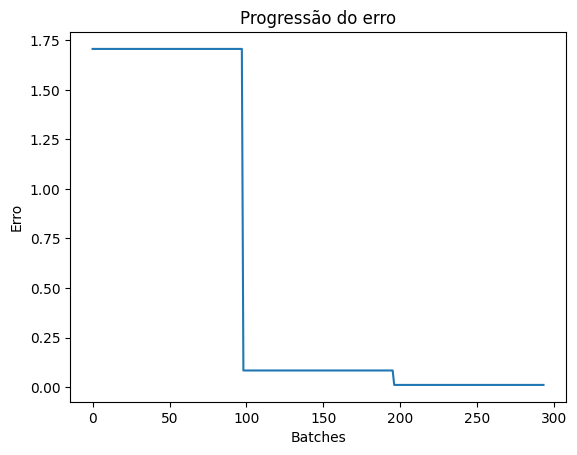

In [145]:
import matplotlib.pyplot as plt
plt.plot(historico_loss)
plt.title('Progressão do erro')
plt.xlabel('Batches')
plt.ylabel('Erro') # quanto mais estável melhor e menor o erro, entre 500 e 600 batches;


O que estabiliza é a Perda (Loss) do modelo.

Quando a linha no gráfico plt.plot(historico_loss) se torna quase horizontal (ou seja, seu valor não diminui mais significativamente a cada novo batch), significa que o modelo alcançou um ponto de estabilidade no aprendizado.


- 1. Convergência

O modelo atingiu a convergência. Isso significa que o algoritmo de otimização (que ajusta os pesos do modelo para reduzir o erro) encontrou o mínimo local (ou global) na função de perda.

Na prática: Ajustar os pesos do modelo (por exemplo, em uma rede neural) com base nos novos dados do batch não resulta mais em uma grande redução do erro. O modelo já aprendeu a maior parte do que o conjunto de dados pode ensinar a ele.


- 2. Ponto de Parada

A estabilização sugere que o modelo está atingindo seu desempenho máximo possível com a arquitetura atual e o conjunto de dados fornecido.

Se a perda estabilizar em um valor baixo: O treinamento foi bem-sucedido, e o modelo está pronto para ser avaliado em dados novos (teste).

Se a perda estabilizar em um valor alto: O modelo pode ter atingido o seu limite de aprendizado, ou há um problema de viés (bias) que pode exigir:

Mais dados de treinamento.

Ajustes na arquitetura do modelo.

Mudanças nos hiperparâmetros (como a taxa de aprendizado).

- 3. Sinais de Overfitting (Sobreajuste)
   
Se o erro de treinamento (a perda do plot) estabilizar e continuar muito baixo, mas o desempenho do modelo em um conjunto de validação começar a piorar (precisaria plotar separadamente), isso é um sinal de Overfitting.

Overfitting ocorre quando o modelo aprende o ruído e as especificidades do conjunto de treinamento tão bem que perde a capacidade de generalizar para dados novos.

Em resumo, a estabilização da linha de erro no gráfico é o sinal de que a fase de aprendizado intenso terminou, e deve prosseguir para a avaliação ou considerar parar o treinamento.



In [147]:
# armazenar o modelo 
modelo.to_disk("modelo_X_twitter")

# Testes com uma frase

In [149]:
modelo_carregado = spacy.load('modelo_X_twitter')
modelo_carregado

## Texto positivo

In [150]:
# ver texto da base de teste
texto_positivo = base_teste['tweet_text'][21]
texto_positivo

'  fico feliz sabendo q recíproco emocaopositiva'

In [152]:
previsao = modelo_carregado(texto_positivo) # tratado
previsao

  fico feliz sabendo q recíproco emocaopositiva

In [154]:
previsao.cats # probabilidade de ser uma frase positiva

{'POSITIVO': 0.9999988079071045, 'NEGATIVO': 1.158087570729549e-06}

In [155]:
# o texto de baixo não está no banco de dados então será feito um pré-processamento
texto_positivo = 'eu gosto muito de você'
texto_positivo = preprocessamento(texto_positivo)
texto_positivo

'gosto'

In [156]:
modelo_carregado(texto_positivo).cats # verifica se é positivo ou negativo

{'POSITIVO': 0.9999856948852539, 'NEGATIVO': 1.4261559954320546e-05}

In [157]:
modelo_carregado(texto_positivo)

gosto

In [158]:
modelo_carregado(texto_positivo).cats

{'POSITIVO': 0.9999856948852539, 'NEGATIVO': 1.4261559954320546e-05}

## Texto negativo

In [159]:
base_teste['tweet_text'][4000]

'tô triste filme mulan mushu emocaonegativa'

In [160]:
texto_negativo = base_teste['tweet_text'][4000]
previsao = modelo_carregado(texto_negativo)
previsao.cats

{'POSITIVO': 2.0905650899294415e-07, 'NEGATIVO': 0.9999997615814209}

# Avaliação do modelo

In [161]:
previsoes = []
for texto in base_teste['tweet_text']:
  previsao = modelo_carregado(texto)
  previsoes.append(previsao.cats)

In [162]:
previsao

  poxaa acho q q vc ta falando q adiaram p dia emocaonegativa biblio engenharia

In [164]:
previsoes[:5]

[{'POSITIVO': 0.9999942779541016, 'NEGATIVO': 5.682510618498782e-06},
 {'POSITIVO': 0.9999979734420776, 'NEGATIVO': 2.0685606614279095e-06},
 {'POSITIVO': 0.9999982118606567, 'NEGATIVO': 1.7922849337992375e-06},
 {'POSITIVO': 0.9999979734420776, 'NEGATIVO': 1.975024360945099e-06},
 {'POSITIVO': 0.999994158744812, 'NEGATIVO': 5.85323277846328e-06}]

In [165]:
previsoes_final = []
for previsao in previsoes:
  if previsao['POSITIVO'] > previsao['NEGATIVO']:
    previsoes_final.append(1)
  else:
    previsoes_final.append(0)

previsoes_final = np.array(previsoes_final)

In [166]:
previsoes_final

array([1, 1, 1, ..., 0, 0, 0])

In [167]:
respostas_reais = base_teste['sentiment'].values

In [168]:
respostas_reais

array([1, 1, 1, ..., 0, 0, 0])

In [169]:
from sklearn.metrics import accuracy_score
accuracy_score(respostas_reais, previsoes_final)

0.9968

In [170]:
acuracia = accuracy_score(respostas_reais, previsoes_final)
print(f'Acurácia {acuracia*100:.2f} %') # se for ter valores 100% pode haver overfitting, o modelo se adapta muito aos dados. 

Acurácia 99.68 %


In [171]:
# mas acurácia alta é boa

In [172]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(respostas_reais, previsoes_final)
cm
# matriz de confusão

array([[2493,    7],
       [   9, 2491]])

In [174]:
#| acertos de positivo |  erros   |
#| erros              | acertos  de negativo|

<Axes: >

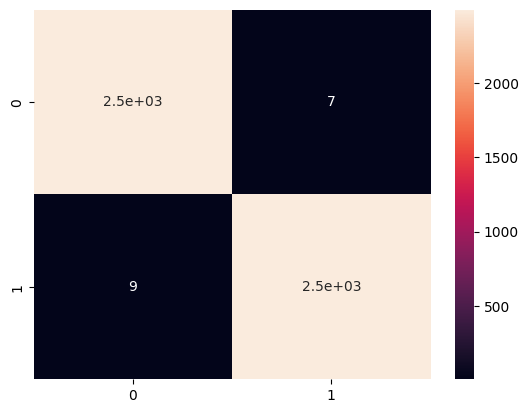

In [176]:
sns.heatmap(cm, annot=True)

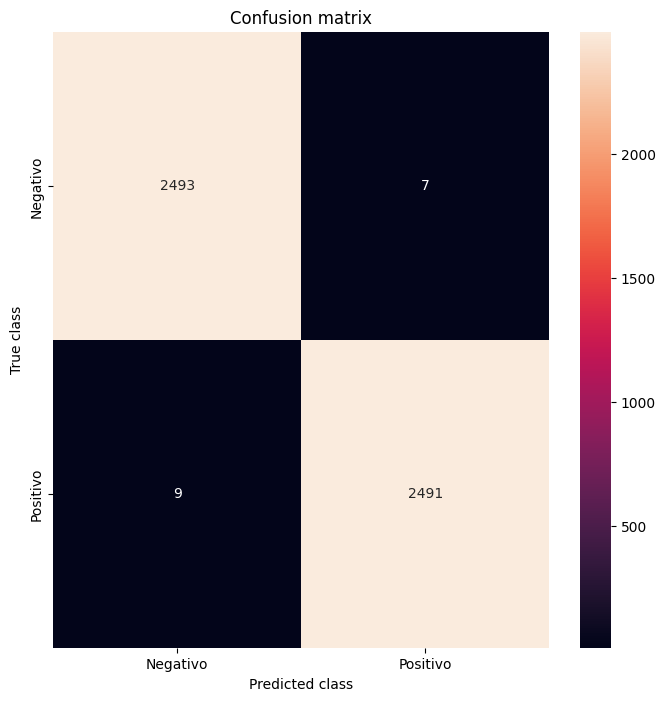

In [177]:
LABELS = ["Negativo", "Positivo"]

plt.figure(figsize=(8, 8))
sns.heatmap(cm, xticklabels=LABELS, yticklabels=LABELS, annot=True, fmt="d")
plt.title("Confusion matrix")
plt.ylabel('True class')
plt.xlabel('Predicted class')
plt.show()

In [178]:
# poucos erros.